# Bölüm 16 — Vision and Multimodal Transformers

> 📚 **Kaynak:** *Hands-On Machine Learning with Scikit-Learn and PyTorch* — Aurélien Géron  
> 🇹🇷 **Açıklamalar:** Türkçe | **Terimler & Kod:** İngilizce  
> 💡 Bu notebook, kitabın 16. bölümündeki tüm örnek kodları içermektedir.

---

## 📋 Bölümün İçeriği

| Konu | Açıklama |
|------|----------|
| **PatchEmbedding** | Görüntüyü patch'lere bölme ve embedding'e çevirme |
| **ViT (Scratch)** | Vision Transformer'ı sıfırdan PyTorch ile inşa etme |
| **ViT Fine-Tuning** | Pretrained ViT'i Oxford Pets veri setine uyarlama |
| **DeiT Fine-Tuning** | Knowledge distillation ile eğitilmiş vision transformer |
| **DINO** | Self-supervised ViT ile görünmeyen segmentasyon |
| **CLIP** | Görüntü-metin kontrastif öğrenme, zero-shot sınıflandırma |
| **Fourier Positional Encoding** | Perceiver için Fourier tabanlı konum kodlama |
| **BLIP-2** | Image captioning — görüntüden metin üretimi |
| **Gemini** | Google'ın multimodal API'si ile görüntü anlama |

---

### 🗺️ Bölümün Haritası

```
Görüntü Transformers (Vision Transformers)
├── ViT        → Görüntüyü patch'lere böl, Transformer encoder'a ver
├── DeiT       → ViT + knowledge distillation (daha az veri ile eğitim)
└── DINO       → Self-supervised ViT, attention map'ler ile segmentasyon

Multimodal Transformers
├── CLIP       → Görüntü + metin birlikte öğrenir (contrastive learning)
├── Perceiver  → Fourier pozisyonel encoding ile herhangi modalite
├── BLIP-2     → ViT + LLM köprüsü (image captioning)
└── Gemini     → Google'ın multimodal büyük dil modeli
```


---
## 🔧 BÖLÜM 1: Ortam Kurulumu (Setup)


In [1]:
import sys

# Python 3.10 veya üzeri gereklidir
# sys.version_info: (major, minor, micro, ...) tuple'ı döndürür
# >= (3, 10) karşılaştırması major.minor kontrolü yapar
assert sys.version_info >= (3, 10)


In [6]:
# Mevcut ortamı temizleyip Python 3.10 ile en güncel PyTorch'u kuralım
!conda create -n torch_env python=3.10 -y
!conda run -n torch_env pip install "torch>=2.6.0" torchvision torchaudio
!conda run -n torch_env pip install ipykernel
!python -m ipykernel install --user --name torch_env --display-name "Python 3.10 (Torch_En Yeni)"

Solving environment: done


==> WARNING: A newer version of conda exists. <==
  current version: 23.3.1
  latest version: 25.7.0

Please update conda by running

    $ conda update -n base -c defaults conda

Or to minimize the number of packages updated during conda update use

     conda install conda=25.7.0



## Package Plan ##

  environment location: /Users/livanurkaranfil/opt/anaconda3/envs/torch_env

  added / updated specs:
    - python=3.10


The following NEW packages will be INSTALLED:

  bzip2              pkgs/main/osx-64::bzip2-1.0.8-h6c40b1e_6 
  ca-certificates    pkgs/main/osx-64::ca-certificates-2025.7.15-hecd8cb5_0 
  expat              pkgs/main/osx-64::expat-2.7.1-h6d0c2b6_0 
  libcxx             pkgs/main/osx-64::libcxx-19.1.7-haebbb44_3 
  libffi             pkgs/main/osx-64::libffi-3.4.4-hecd8cb5_1 
  ncurses            pkgs/main/osx-64::ncurses-6.5-h923df54_0 
  openssl            pkgs/main/osx-64::openssl-3.0.17-hee2dfae_0 
  pip                pkgs/main/noarc

In [3]:
# Doğrudan resmi PyTorch kanalından çekiyoruz
!pip install torch==2.2.2 torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


In [ ]:
# Hangi platformda çalıştığımızı tespit et
# sys.modules: O an yüklü tüm Python modüllerinin sözlüğü
IN_COLAB = "google.colab" in sys.modules    # Google Colab'da mıyız?
IN_KAGGLE = "kaggle_secrets" in sys.modules  # Kaggle Kernels'ta mıyız?


In [ ]:
# Colab'da torchmetrics önceden kurulu değil → manuel kur
# %pip: Jupyter magic komutu — notebook ortamında pip çalıştırır
# -q: quiet modu (kısa çıktı)
if IS_COLAB:
    %pip install -q torchmetrics


In [11]:
!pip uninstall -y numpy
!pip install "numpy<2"

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
  Using cached numpy-1.26.4-cp39-cp39-macosx_10_9_x86_64.whl.metadata (61 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 35.7 kB/s  0:09:33m0:00:0600:16
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.55.1 requires numpy<1.22,>=1.18, but you have numpy 1.26.4 which is incompatible.
scipy 1.9.3 requires numpy<1.26.0,>=1.18.5, but you have numpy 1.26.4 which is incompatible.


In [13]:
import torch
# Öncelik sırası: CUDA (NVIDIA GPU) > MPS (Apple Silicon) > CPU
if torch.cuda.is_available():
    device = "cuda"    # NVIDIA GPU — en hızlı seçenek
elif torch.backends.mps.is_available():
    device = "mps"     # Apple M1/M2/M3 GPU
else:
    device = "cpu"     # Yedek seçenek — çok yavaş olabilir

print(f"Kullanılan device: {device}")
device


Kullanılan device: mps


'mps'

In [ ]:
if device == "cpu":
    print("Neural nets can be very slow without a hardware accelerator.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")


In [1]:
import matplotlib.pyplot as plt

# Tüm grafiklerde tutarlı yazı boyutları
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)


In [11]:
!pip install tokenizers numexpr

  Using cached tokenizers-0.22.2-cp39-abi3-macosx_10_12_x86_64.whl.metadata (7.3 kB)
Using cached tokenizers-0.22.2-cp39-abi3-macosx_10_12_x86_64.whl (3.1 MB)


In [2]:
!pip install transformers

  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_10_12_x86_64.whl.metadata (4.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 39.9 kB/s  0:05:27m0:00:0600:12
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
Using cached safetensors-0.7.0-cp38-abi3-macosx_10_12_x86_64.whl (467 kB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 1.6.0
    Can't uninstall 'huggingface-hub'. No files were found to uninstall.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [transformers] [transformers]ub]


In [4]:
!pip uninstall -y scikit-learn
!pip install --upgrade scikit-learn

Found existing installation: scikit-learn 1.1.3
Uninstalling scikit-learn-1.1.3:
  Successfully uninstalled scikit-learn-1.1.3
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.8/20.8 MB 19.1 kB/s  0:11:37m0:00:0700:15
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 2.2.0
    Uninstalling threadpoolctl-2.2.0:
      Successfully uninstalled threadpoolctl-2.2.00m 0/2 [threadpoolctl]
  Attempting uninstall: numpy━━━━━━━━━━━━━━━ 0/2 [threadpoolctl]
    Found existing installation: numpy 1.26.4 0/2 [threadpoolctl]
    Uninstalling numpy-1.26.4:━━━━━━━━━━━━━━ 0/2 [threadpoolctl]
      Successfully uninstalled numpy-1.26.4━ 0/2 [threadpoolctl]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [numpy]32m1/2 [numpy]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is

---
## 🔷 BÖLÜM 2: Vision Transformers (ViT)

### Transformer Görüntülere Nasıl Uygulanır?

NLP'de Transformer, bir cümleyi token dizisi olarak işler.  
Görüntüler için aynı fikri uygulamak için görüntüyü **patch** adı verilen küçük parçalara böleriz.

### Patch Nedir?

Patch, görüntünün küçük bir dikdörtgen kesiti. Örneğin:
- 224×224 piksel görüntü + 16×16 patch boyutu → **(224/16)² = 196 patch**
- Her patch 16×16×3 = 768 piksel değeri içerir
- Bu değerler doğrusallaştırılıp (flatten) embedding'e dönüştürülür
- Artık elimizde 196 "görüntü tokeni" var — tıpkı bir cümledeki 196 kelime gibi!

### ViT Mimarisi (Genel Bakış)

```
Girdi Görüntü (224×224×3)
    ↓
[Patch Embedding]  → 196 patch → her biri 768 boyutlu vektöre
    ↓
[CLS Token Ekleme] → 1 özel token + 196 patch = 197 token
    ↓
[Positional Embedding] → Her token'a konum bilgisi ekle
    ↓
[Transformer Encoder × 12] → Self-attention ile patch'ler arası ilişki
    ↓
[CLS Token Çıktısı] → Tüm görüntüyü özetleyen vektör
    ↓
[Linear Classifier] → Sınıf tahmini
```


### 2.1 PatchEmbedding — Görüntüyü Patch'lere Böl

**Akıllı Teknik:** Görüntüyü patch'lere bölmek için özel bir döngü yazmak yerine **Conv2D** kullanıyoruz!

`Conv2D(kernel_size=patch_size, stride=patch_size)` ile:
- `kernel_size=16, stride=16`: Birbiriyle örtüşmeyen 16×16 pencereler
- Her pencere (patch), `embed_dim` boyutlu bir vektöre dönüştürülür
- Bu hem daha verimli hem de GPU'da paralel çalışır

**Neden bu teknik işe yarıyor?**  
Stride = kernel_size olduğunda, convolution pencereleri birbiriyle örtüşmez.  
Her pencere tam olarak bir patch'e karşılık gelir → 196 bağımsız projeksiyon.


In [2]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    """
    Görüntüyü patch'lere bölerek embedding'e dönüştürür.
    
    Conv2D trick kullanılır: kernel_size=stride=patch_size
    → Birbiriyle örtüşmeyen patch'ler + eş zamanlı linear projeksiyon
    
    Parametreler:
    - in_channels: Giriş görüntüsünün kanal sayısı (RGB için 3)
    - embed_dim:   Her patch'in dönüştürüleceği vektör boyutu (örn. 768)
    - patch_size:  Her patch'in boyutu (hem yükseklik hem genişlik, örn. 16)
    """
    def __init__(self, in_channels, embed_dim, patch_size=16):
        super().__init__()
        # Conv2D ile patch'lere böl VE aynı anda embedding'e dönüştür
        # in_channels → embed_dim: Her patch 768 boyutlu vektöre projeksiyon
        # kernel_size=patch_size: Her convolution penceresi tam bir patch
        # stride=patch_size: Pencereler örtüşmüyor → her patch bir kez işlenir
        self.conv2d = nn.Conv2d(in_channels, embed_dim,
                                kernel_size=patch_size, stride=patch_size)

    def forward(self, X):
        """
        X: (B, C, H, W) — batch görüntüler
        
        Adımlar:
        1. Conv2D: (B, C, H, W) → (B, embed_dim, H/p, W/p)
           patch_size=16, img=224: (B, 768, 14, 14)
        2. flatten(start_dim=2): (B, embed_dim, H/p, W/p) → (B, embed_dim, num_patches)
           (B, 768, 14, 14) → (B, 768, 196)
        3. transpose(1,2): (B, embed_dim, num_patches) → (B, num_patches, embed_dim)
           (B, 768, 196) → (B, 196, 768)
           
        Transformer (B, seq_len, embed_dim) formatını bekler — bu yüzden transpose
        """
        X = self.conv2d(X)          # (B, embed_dim, H/p, W/p)
        X = X.flatten(start_dim=2)  # (B, embed_dim, num_patches)
        return X.transpose(1, 2)    # (B, num_patches, embed_dim)


### 2.2 ViT — Tam Vision Transformer Modeli

#### CLS Token Nedir?

BERT'ten esinlenerek ViT, patch dizisinin başına özel bir **[CLS] tokeni** ekler.  
Bu token:
- Eğitim sırasında tüm patch'lere dikkat ederek (attention) görüntüyü özetler
- Final çıktıdaki CLS token vektörü, görüntü sınıflandırması için kullanılır
- Tüm görüntünün "özeti" olarak düşünülebilir

#### GELU Aktivasyon

ViT, FFN (Feed-Forward Network) aktivasyonu olarak **GELU (Gaussian Error Linear Unit)** kullanır — ReLU yerine.  
GELU daha yumuşak bir geçiş sağlar ve büyük modellerde genellikle daha iyi performans verir.

#### Mimarinin Parametreleri (ViT-Base)

| Parametre | Değer | Açıklama |
|-----------|-------|----------|
| img_size | 224 | Giriş görüntüsü boyutu |
| patch_size | 16 | Her patch'in boyutu |
| embed_dim | 768 | Embedding boyutu |
| depth | 12 | Encoder katman sayısı |
| num_heads | 12 | MHA başlık sayısı |
| ff_dim | 3072 | FFN gizli boyutu (768 × 4) |


In [3]:
class ViT(nn.Module):
    """
    Vision Transformer (ViT) — 'An Image is Worth 16x16 Words' makalesi.
    
    Orijinal mimari: ViT-Base/16
    - 224×224 görüntü, 16×16 patch → 196 patch
    - 768 boyutlu embedding, 12 katman, 12 başlık
    - ~86M parametre
    
    Parametreler:
    - img_size:    Giriş görüntüsünün boyutu (kare varsayılır)
    - patch_size:  Her patch'in boyutu
    - in_channels: Görüntü kanalları (RGB=3)
    - num_classes: Sınıflandırma çıktı sayısı
    - embed_dim:   Embedding boyutu
    - depth:       Transformer Encoder katman sayısı
    - num_heads:   Multi-Head Attention başlık sayısı
    - ff_dim:      Feed-Forward Network gizli katman boyutu
    - dropout:     Dropout oranı
    """
    def __init__(self, img_size=224, patch_size=16, in_channels=3,
                 num_classes=1000, embed_dim=768, depth=12, num_heads=12,
                 ff_dim=3072, dropout=0.1):
        super().__init__()

        # ── Patch Embedding ──
        # Görüntüyü patch'lere böl ve her birini embed_dim boyutuna projeksiyon yap
        self.patch_embed = PatchEmbedding(in_channels, embed_dim, patch_size)

        # ── CLS Token ──
        # (1, 1, embed_dim) boyutlu öğrenilebilir token
        # Her forward pass'te batch boyutuna genişletilir: (B, 1, embed_dim)
        # Bu token tüm görüntü bilgisini toplar → sınıflandırma için kullanılır
        cls_init = torch.randn(1, 1, embed_dim) * 0.02  # Küçük rastgele başlatma
        self.cls_token = nn.Parameter(cls_init)  # Eğitim sırasında öğrenilir

        # ── Positional Embedding ──
        # num_patches: (img_size / patch_size)^2 = (224/16)^2 = 196
        # +1: CLS token için bir ek pozisyon
        # (1, num_patches+1, embed_dim) boyutlu öğrenilebilir pozisyon vektörleri
        num_patches = (img_size // patch_size) ** 2  # 196
        pos_init = torch.randn(1, num_patches + 1, embed_dim) * 0.02
        self.pos_embed = nn.Parameter(pos_init)  # (1, 197, 768)

        self.dropout = nn.Dropout(p=dropout)

        # ── Transformer Encoder ──
        # activation='gelu': GELU aktivasyonu — ViT'in orijinal kullandığı
        # batch_first=True: (batch, seq, feature) format standardı
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation="gelu",    # ReLU yerine GELU (daha yumuşak geçiş)
            batch_first=True)

        # depth adet encoder katmanını üst üste yığ
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        # ── Final LayerNorm ve Classifier ──
        self.layer_norm = nn.LayerNorm(embed_dim)   # CLS token çıktısını normalize et
        self.output = nn.Linear(embed_dim, num_classes)  # Sınıflandırıcı başlık

    def forward(self, X):
        """
        X: (B, C, H, W) — batch görüntüler
        
        Adım adım:
        1. Patch embedding: (B, C, H, W) → (B, L, E)   L=num_patches, E=embed_dim
        2. CLS token ekle:  (B, L, E) → (B, 1+L, E)
        3. Pozisyon ekle:   (B, 1+L, E) + (1, 1+L, E) → (B, 1+L, E)
        4. Encoder:         (B, 1+L, E) → (B, 1+L, E)
        5. CLS al + norm:   (B, E)
        6. Sınıflandır:     (B, num_classes)
        """
        # Adım 1: Patch embedding
        Z = self.patch_embed(X)  # (B, L, E)  — L=196, E=768

        # Adım 2: CLS token'ı batch boyutuna genişlet ve başa ekle
        # cls_token: (1, 1, E) → expand ile (B, 1, E) yapılır
        # expand: bellek kopyalamadan sanal olarak genişletir
        cls_expd = self.cls_token.expand(Z.shape[0], -1, -1)  # (B, 1, E)
        Z = torch.cat((cls_expd, Z), dim=1)  # (B, 1+L, E) = (B, 197, 768)

        # Adım 3: Pozisyonel embedding ekle (element-wise toplama)
        # pos_embed: (1, 197, 768) — broadcast ile her batch örneğine eklenir
        Z = Z + self.pos_embed  # (B, 197, 768)
        Z = self.dropout(Z)     # Regularization

        # Adım 4: Transformer Encoder — tüm patch'ler arası self-attention
        Z = self.encoder(Z)  # (B, 197, 768)

        # Adım 5: Sadece CLS token'ının çıktısını al (indeks 0)
        # CLS token tüm görüntüyü temsil eden özet vektör
        Z = self.layer_norm(Z[:, 0])  # (B, 768) — her görüntü için bir vektör

        # Adım 6: Sınıflandırıcı linear katman
        logits = self.output(Z)  # (B, num_classes) = (B, 1000)
        return logits


### 2.3 ViT Modelini Test Etme

Modeli oluşturup rastgele bir batch üzerinde çalıştıralım.


In [4]:
# ViT-Base/16 modelini oluştur (orijinal makale boyutları)
vit_model = ViT(
    img_size=224,      # 224×224 piksel giriş
    patch_size=16,     # 16×16 patch boyutu → 196 patch
    in_channels=3,     # RGB görüntü
    num_classes=1000,  # ImageNet: 1000 sınıf
    embed_dim=768,     # Embedding boyutu
    depth=12,          # 12 Transformer Encoder katmanı
    num_heads=12,      # 12 MHA başlığı (768/12 = 64 d_k)
    ff_dim=3072,       # FFN gizli boyutu (768 × 4)
    dropout=0.1
)

# Rastgele bir batch oluştur: 4 görüntü, RGB, 224×224
batch = torch.randn(4, 3, 224, 224)

# Forward pass (gradyan hesaplama gerek yok — sadece shape kontrolü)
logits = vit_model(batch)  # Beklenen çıktı: (4, 1000)
print(f"Batch boyutu: {batch.shape}")
print(f"Logits boyutu: {logits.shape}")


Batch boyutu: torch.Size([4, 3, 224, 224])
Logits boyutu: torch.Size([4, 1000])


In [5]:
# Çıktı boyutunu doğrula
print(f"logits.shape = {logits.shape}")
# Beklenen: torch.Size([4, 1000])
# 4 görüntü × 1000 sınıf


logits.shape = torch.Size([4, 1000])


---
## 🔷 BÖLÜM 3: Pretrained ViT Fine-Tuning — Oxford Pets

### Transfer Learning ile Fine-Tuning

Sıfırdan ViT eğitmek milyonlarca görüntü ve haftalarca GPU süresi gerektirir.  
Bunun yerine **pretrained** modeli indirip kendi veri setimize **fine-tune** ediyoruz.

**Strateji:**
- `google/vit-base-patch16-224-in21k`: ImageNet-21K üzerinde pretrained (14M görüntü, 21K sınıf)
- Sadece son sınıflandırıcı başlığı değiştirilir: 21K → 37 sınıf
- Tüm model birkaç epoch ile pets veri setine uyarlanır

### Oxford-IIIT Pet Dataset

- 37 farklı kedi ve köpek ırkı
- ~7400 eğitim görüntüsü
- Bu küçük veri setinde sıfırdan eğitim çok zayıf sonuç verirdi
- Transfer learning ile mükemmel sonuçlar alınabilir


In [6]:
from datasets import load_dataset

# Oxford-IIIT Pet veri setini Hugging Face Hub'dan indir
# timm/oxford-iiit-pet: timm formatında hazırlanmış versiyon
# - 'train' split: ~7400 görüntü
# - 'test' split: ~3669 görüntü
# Her örnek 'image' (PIL Image) ve 'label' (int 0-36) içerir
pets = load_dataset("timm/oxford-iiit-pet")
print(pets)


/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


README.md: 0.00B [00:00, ?B/s]

/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


data/train-00000-of-00001.parquet:   0%|          | 0.00/378M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/413M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3680 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3669 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'image_id', 'label_cat_dog'],
        num_rows: 3680
    })
    test: Dataset({
        features: ['image', 'label', 'image_id', 'label_cat_dog'],
        num_rows: 3669
    })
})


### 3.1 Veri Setini Görselleştirme

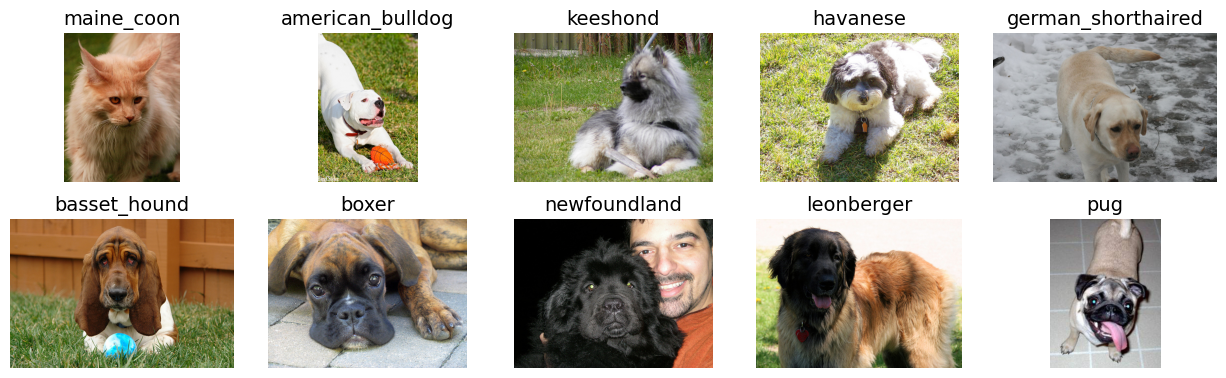

In [8]:
# İlk 10 eğitim görüntüsünü 2×5 grid olarak göster
num_rows, num_cols = 2, 5
plt.figure(figsize=(num_cols * 2.5, num_rows * 2))

# class_names: 37 ırkın string isimlerini içeren liste
# pets["train"].features["label"].names ile alınır
class_names = pets["train"].features["label"].names

for i in range(num_rows * num_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    example = pets["train"][i]
    plt.imshow(example["image"])                    # PIL Image nesnesini göster
    plt.title(class_names[example["label"]])        # Irk adını başlık olarak yaz
    plt.axis("off")                                  # Eksen etiketlerini kaldır

plt.tight_layout()
plt.show()


### 3.2 Pretrained ViT Modelini ve Processor'ı Yükleme

**ViTForImageClassification:** Sınıflandırma başlığı olan ViT.  
`num_labels=37` ile son katmanı 37 sınıfa uyarlanır.

**AutoImageProcessor:** Görüntüleri model için hazırlayan araç. Şunları yapar:
- Görüntüyü 224×224'e yeniden boyutlandırır (resize)
- RGB'ye çevirir (do_convert_rgb=True)
- Piksel değerlerini [-1, 1] aralığına normalize eder
- PyTorch tensörüne çevirir


In [3]:
from transformers import ViTForImageClassification, AutoImageProcessor

# Google'ın ImageNet-21K üzerinde pretrained ViT-Base modeli
# 'patch16-224': 16×16 patch, 224×224 giriş
# 'in21k': ImageNet-21K (14M görüntü, 21,843 sınıf) ile pretrained
model_id = "google/vit-base-patch16-224-in21k"

# ViTForImageClassification: ViT encoder + sınıflandırma başlığı
# num_labels=37: Son Linear katmanı 37 sınıfa ayarla (Pets için)
# Bu, pretrained ağırlıkları korurken sadece son katmanı değiştirir
vit_model = ViTForImageClassification.from_pretrained(model_id, num_labels=37)

# AutoImageProcessor: Görüntü ön işleme pipeline'ı
# use_fast=True: Hızlı işlemci kullan (Rust tabanlı)
# Model için gerekli tüm normalizasyon ayarlarını otomatik yükler
vit_processor = AutoImageProcessor.from_pretrained(model_id, use_fast=True)


/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


ImportError: cannot import name 'METRIC_MAPPING64' from 'sklearn.metrics._dist_metrics' (/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_dist_metrics.cpython-39-darwin.so)

### 3.3 Processor'ın Yapılandırmasını İnceleme

In [ ]:
# Processor'ın ne yaptığını göster:
# - do_resize: True (224×224'e yeniden boyutlandır)
# - do_normalize: True (mean ve std ile normalize et)
# - image_mean: [0.5, 0.5, 0.5] (RGB kanalları için ortalama)
# - image_std: [0.5, 0.5, 0.5] (RGB kanalları için standart sapma)
# Bu normalize işlemi piksel değerlerini [-1, 1] aralığına çeker
print(vit_processor)


### 3.4 İşlenmiş Görüntüleri Görselleştirme

Processor'dan geçen görüntülerin nasıl göründüğünü kontrol edelim.

In [ ]:
num_rows, num_cols = 2, 5
plt.figure(figsize=(num_cols * 2.5, num_rows * 2))
class_names = pets["train"].features["label"].names

for i in range(num_rows * num_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    example = pets["train"][i]

    # Görüntüyü processor'dan geçir
    # preprocessed: normalize edilmiş float tensörü (C, H, W) boyutunda
    # "pixel_values"[0]: Batch'ten ilk (ve tek) görüntüyü al
    preprocessed = vit_processor(example["image"])["pixel_values"][0]

    # Görselleştirme için:
    # 1. permute(1, 2, 0): (C, H, W) → (H, W, C) — matplotlib formatı
    # 2. + 1.0 ve / 2.0: [-1, 1] → [0, 1] aralığına çevir (imshow için)
    plt.imshow((preprocessed.permute(1, 2, 0) + 1.) / 2.)
    plt.title(class_names[example["label"]])
    plt.axis("off")

# Not: Tüm görüntüler artık kare (224×224) ve normalize edilmiş
plt.tight_layout()
plt.show()


### 3.5 Collate Fonksiyonu

`DataLoader`'ın her batch'i oluştururken çağıracağı fonksiyon.  
Ham PIL görüntülerini model'in beklediği formata dönüştürür.


In [ ]:
def vit_collate_fn(batch):
    """
    DataLoader'ın her batch için çağırdığı fonksiyon.
    
    Ham veri (PIL Image + int label) → Model girdisi (tensörler sözlüğü)
    
    Parametreler:
    - batch: Veri setinden gelen örnek listesi
             Her örnek {'image': PIL Image, 'label': int} sözlüğü
    
    Döndürür:
    - inputs: {'pixel_values': tensor(B,3,224,224), 'labels': tensor(B,)}
    """
    # Her örnekten görüntü ve etiketleri topla
    images = [example["image"] for example in batch]
    labels = [example["label"] for example in batch]

    # Tüm görüntüleri batch halinde processor'dan geçir
    # return_tensors='pt': PyTorch tensor olarak döndür
    # do_convert_rgb=True: RGBA veya grayscale görüntüleri RGB'ye çevir
    inputs = vit_processor(images, return_tensors="pt", do_convert_rgb=True)

    # Etiketleri tensöre çevir ve inputs sözlüğüne ekle
    # Trainer API, 'labels' anahtarını otomatik olarak loss hesabında kullanır
    inputs["labels"] = torch.tensor(labels)
    return inputs


### 3.6 Doğruluk (Accuracy) Metriği

In [ ]:
# compute_metrics: Trainer API'sinin her evaluation adımında çağırdığı fonksiyon
# Logits ve gerçek etiketleri alır, metrik sözlüğü döndürür

def compute_accuracy(logits_and_labels):
    """
    Model tahminleri ile gerçek etiketleri karşılaştırarak doğruluk hesaplar.
    
    Parametreler:
    - logits_and_labels: (logits_array, labels_array) tuple'ı
                         logits: (N, num_classes) — ham tahmin skorları
                         labels: (N,) — gerçek sınıf indeksleri
    
    Döndürür:
    - {'accuracy': float} — 0.0 ile 1.0 arasında doğruluk
    """
    logits, labels = logits_and_labels

    # En yüksek logit değerine sahip sınıfı tahmin olarak seç
    preds = torch.tensor(logits).argmax(dim=1)   # (N,) — tahmin edilen sınıflar
    labels = torch.tensor(labels)

    # Doğru tahmin oranı hesapla
    accuracy = (preds == labels).float().mean()
    return {"accuracy": accuracy.item()}


### 3.7 ViT'i Fine-Tune Etme — Hugging Face Trainer

**TrainingArguments Parametreleri:**
- `eval_strategy="epoch"`: Her epoch sonunda validation set üzerinde değerlendir
- `remove_unused_columns=False`: Dataset'teki 'image' sütununu silme (collate_fn kullanıyor)
- `per_device_train_batch_size=16`: Her GPU'da 16 görüntü işle


In [ ]:
from transformers import Trainer, TrainingArguments

# Eğitim konfigürasyonu
args = TrainingArguments(
    "my_pets_vit",                      # Checkpoint kayıt klasörü
    per_device_train_batch_size=16,     # GPU başına batch boyutu
    eval_strategy="epoch",              # Her epoch sonunda değerlendir
    num_train_epochs=3,                 # 3 tam epoch
    remove_unused_columns=False,        # 'image' sütununu sakla (collate_fn için)
    report_to="none"                    # WandB/TensorBoard raporlamasını kapat
)

# Trainer: Tüm eğitim döngüsünü yönetir
trainer = Trainer(
    model=vit_model,                # Fine-tune edilecek model
    args=args,                      # Eğitim ayarları
    data_collator=vit_collate_fn,   # Batch oluşturma fonksiyonu
    train_dataset=pets["train"],    # Eğitim seti (~7400 görüntü)
    eval_dataset=pets["test"],      # Test seti (~3669 görüntü)
    compute_metrics=compute_accuracy # Metrik hesaplama fonksiyonu
)

# Eğitimi başlat
# GPU ile ~5-10 dakika sürer
# Beklenen final doğruluk: ~%90+ (pretrained model sayesinde)
train_output = trainer.train()


---
## 🔷 BÖLÜM 4: DeiT Fine-Tuning — Data-efficient Image Transformers

### DeiT Nedir?

**DeiT (Data-Efficient Image Transformers)**, Facebook AI tarafından 2020'de yayınlandı.  
ViT ile aynı mimariye sahip ama **çok daha az veri ile** eğitilebilir.

### Neden ViT Az Veri ile Zayıf?

ViT, görüntülerin yerel yapısına dair içsel bir önyargı (inductive bias) içermez.  
CNN'ler "yakın pikseller ilişkilidir" varsayımını mimariye gömülü taşırken,  
ViT bunu sıfırdan öğrenmek zorunda → **çok veri gerektirir.**

### DeiT'in Çözümü: Knowledge Distillation (Bilgi Damıtma)

1. Önce bir **teacher model** (CNN — ResNet gibi) görüntüler üzerinde eğitilir
2. Sonra ViT (**student**) hem gerçek etiketlerden hem teacher'ın tahminlerinden öğrenir
3. Bu sayede CNN'in "yerel örüntüler" bilgisi ViT'e aktarılır

### Distillation Token

DeiT, CLS token'a ek olarak bir **distillation token** ekler:
- CLS token: Gerçek etiketlerden öğrenir (normal sınıflandırma)
- Distillation token: Teacher model tahminlerinden öğrenir
- Her iki token da tüm patch'lere attention yapar


In [ ]:
from transformers import DeiTForImageClassification, AutoImageProcessor

# Facebook'un DeiT-Base modeli
# 'distilled': Knowledge distillation ile eğitilmiş
# 'patch16-224': 16×16 patch, 224×224 giriş
model_id = "facebook/deit-base-distilled-patch16-224"

# DeiTForImageClassification: DeiT + sınıflandırma başlıkları
# num_labels=37: Pets için 37 sınıf
# Hem CLS hem distillation başlığı 37 sınıfa ayarlanır
deit_model = DeiTForImageClassification.from_pretrained(model_id, num_labels=37)

# AutoImageProcessor: DeiT için ön işleme konfigürasyonunu yükle
# ViT processor ile benzer ama DeiT'e özgü normalizasyon parametreleri olabilir
deit_processor = AutoImageProcessor.from_pretrained(model_id, use_fast=True)


### 4.1 DeiT Collate Fonksiyonu

In [ ]:
def deit_collate_fn(batch):
    """
    DeiT için collate fonksiyonu — vit_collate_fn ile aynı yapıda.
    
    Tek fark: deit_processor kullanılması.
    DeiT ve ViT aynı 224×224 girdi formatını kullanır.
    """
    images = [example["image"] for example in batch]
    labels = [example["label"] for example in batch]

    # deit_processor: DeiT'e özgü normalizasyon parametreleri ile işle
    inputs = deit_processor(images, return_tensors="pt", do_convert_rgb=True)
    inputs["labels"] = torch.tensor(labels)
    return inputs


### 4.2 DeiT'i Fine-Tune Etme

In [ ]:
from transformers import Trainer, TrainingArguments

# Aynı eğitim ayarları — sadece output klasörü farklı
args = TrainingArguments(
    "my_pets_deit",                     # Checkpoint kayıt klasörü
    per_device_train_batch_size=16,
    eval_strategy="epoch",
    num_train_epochs=3,
    remove_unused_columns=False,
    report_to="none"
)

# DeiT trainer
trainer = Trainer(
    model=deit_model,
    args=args,
    data_collator=deit_collate_fn,   # DeiT için collate fonksiyonu
    train_dataset=pets["train"],
    eval_dataset=pets["test"],
    compute_metrics=compute_accuracy
)

# Eğitim başlat
# DeiT, ViT kadar büyük ama knowledge distillation sayesinde
# daha az veri / daha kısa sürede benzer doğruluk elde edilebilir
train_output = trainer.train()


---
## 🔷 BÖLÜM 5: DINO — Self-Supervised ViT ile Segmentasyon

### DINO Nedir?

**DINO (Self-DIstillation with NO labels)**, Facebook AI tarafından 2021'de yayınlandı.  
Etiket **kullanmadan** görüntü özelliklerini öğrenen self-supervised bir yöntem.

### Nasıl Çalışır?

DINO bir **teacher-student** düzeneği kullanır:
- **Student ağ:** Normal gradient descent ile güncellenir
- **Teacher ağ:** Student'ın ağırlıklarının **exponential moving average**'i (ema)
- Her iki ağ da aynı görüntünün farklı crop'larını görür
- Student, teacher'ın çıktısını tahmin etmeyi öğrenir (labels olmadan!)

### Neden Dikkat Çekici?

DINO'nun en ilginç özelliği: Attention map'lerine bakıldığında,  
model **etiket görmeden** nesneleri segmente etmeyi öğreniyor!  
CLS token, resmin semantik yapısına ilgi gösteren bölgeleri otomatik keşfediyor.

### vitb8 Modeli

`dino-vitb8`: patch boyutu 8×8 kullanır (patch16 yerine)  
- 224/8 = 28 → 28×28 = **784 patch** (patch16'nın 196 patch'ine kıyasla 4× daha fazla)  
- Daha ince grain attention map'ler → daha iyi segmentasyon


In [ ]:
from PIL import Image
import urllib.request

# COCO veri setinden iki kediyi gösteren örnek görüntü
image_url = 'http://images.cocodataset.org/val2017/000000039769.jpg'

# urllib.request.urlopen: URL'den dosya aç
# Image.open: PIL Image nesnesine çevir
image = Image.open(urllib.request.urlopen(image_url))
print(f"Görüntü boyutu: {image.size}")  # (width, height)
image


### 5.1 DINO Modelini Yükleme

In [ ]:
from transformers import AutoImageProcessor, AutoModel

# facebook/dino-vitb8: ViT-Base mimarisinde, patch_size=8, DINO ile eğitilmiş
# output_attentions=True: Forward pass'te attention ağırlıklarını da döndür
#                         Bu olmadan attention map görselleştirme yapamayız
model_id = "facebook/dino-vitb8"
model = AutoModel.from_pretrained(model_id, output_attentions=True)

# AutoImageProcessor: DINO modeli için uygun ön işleme
# do_convert_rgb=True: Görüntüyü RGB'ye çevir
processor = AutoImageProcessor.from_pretrained(model_id, do_convert_rgb=True)

print("Model yüklendi ✓")


### 5.2 Forward Pass ve CLS Token Çıktısı

In [ ]:
# Görüntüyü ön işle ve modele gönder
inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():   # Inference — gradyan hesaplama
    output = model(**inputs)

# output.last_hidden_state: Son encoder katmanının çıktıları
# Boyut: (1, 1+num_patches, embed_dim) = (1, 785, 768)
# - İndeks 0: CLS token çıktısı
# - İndeks 1-784: 784 patch token çıktısı (28×28 grid)
cls_token_output = output.last_hidden_state[:, 0]
print(f"CLS token çıktı boyutu: {cls_token_output.shape}")
# Beklenen: (1, 768) — batch_size=1, embed_dim=768


### 5.3 Attention Map'leri Çıkarma

DINO'nun attention map'leri görüntünün hangi bölgelerine dikkat edildiğini gösterir.

**Hangi attention kullanılır?**

CLS token'ın patch token'larına verdiği dikkat (CLS→Patch) yerine,  
**patch token'larının CLS token'a verdiği dikkat (Patch→CLS)** daha iyi sonuç verir.

Sebep: Her patch "CLS token ne kadar önemli?" sorusunu yanıtlar.  
Yüksek attention → o patch görüntünün önemli bölgesine karşılık gelir.


In [ ]:
# output.attentions: Her encoder katmanının attention ağırlıkları listesi
# [-1]: En son (12.) katmanın attention'ları — en anlamlı özellikler burada
last_layer_attention_maps = output.attentions[-1]
print(f"Attention maps boyutu: {last_layer_attention_maps.shape}")
# (1, 12, 785, 785): batch=1, heads=12, queries=785, keys=785

# Patch-to-CLS attention çıkar:
# [0]: Batch'ten ilk örnek
# [:, 1:, 0]: Tüm başlıklar, patch token'lar (1'den sona), CLS token (0. indeks)
# Yani: Her patch'in CLS token'a ne kadar dikkat ettiği
cls_attn = last_layer_attention_maps[0, :, 1:, 0]
print(f"CLS attention boyutu: {cls_attn.shape}")
# Beklenen: (12, 784) — 12 başlık, 784 patch


### 5.4 Attention Map'leri Görselleştirme

Her attention başlığı farklı görüntü özelliklerine odaklanır:
- Bazı başlıklar nesnelerin kenarlarını yakalar
- Bazıları arka planı vs. ön planı ayırt eder
- Bazıları belirli nesne parçalarına (kuyruğa, göze vb.) odaklanır

Dikkat edecek olursak: **Etiket olmadan** model kedilerin konumunu öğrenmiş!


In [ ]:
import torchvision.transforms.functional as TF

num_heads, num_patches = cls_attn.shape  # 12, 784

# Patch grid boyutunu hesapla: 784 = 28×28
size = int(num_patches ** 0.5)  # 28

plt.figure(figsize=(12, 7))

for head_index in range(12):  # 12 attention başlığını görselleştir
    plt.subplot(3, 4, head_index + 1)

    # Her başlığın attention vektörünü 2D grid'e yeniden şekillendir
    attn = cls_attn[head_index].reshape(size, size)  # (28, 28)

    # TF.resize: Attention map'i orijinal görüntü boyutuna büyüt
    # unsqueeze(0).unsqueeze(0): (28,28) → (1,1,28,28) — torchvision formatı
    # BILINEAR interpolasyon: Pürüzsüz büyütme
    attn_map = attn.unsqueeze(0).unsqueeze(0)
    attn_resized = TF.resize(attn_map, image.size[::-1],  # image.size: (W,H) → [::-1]: (H,W)
                             interpolation=TF.InterpolationMode.BILINEAR)[0, 0]

    # Orijinal görüntünün üzerine attention map'i bindir
    plt.imshow(image)                                    # Orijinal görüntü
    plt.imshow(attn_resized.numpy(), cmap='jet', alpha=0.5)  # Attention overlay
    # cmap='jet': Düşük dikkat (mavi) → Yüksek dikkat (kırmızı)
    # alpha=0.5: %50 saydamlık — her iki görüntü de görünür
    plt.axis('off')
    plt.title(f"Head {head_index+1}", fontsize=10)

plt.suptitle("DINO Attention Maps — Her Başlık Farklı Bölgelere Odaklanıyor",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


---
## 🔷 BÖLÜM 6: CLIP — Contrastive Language-Image Pre-Training

### CLIP Nedir?

**CLIP (Contrastive Language-Image Pre-Training)**, OpenAI tarafından 2021'de yayınlandı.  
İki bileşenden oluşur:
1. **Görüntü Encoder:** ViT (veya ResNet) — görüntüyü sabit boyutlu vektöre dönüştürür
2. **Metin Encoder:** Transformer — metni sabit boyutlu vektöre dönüştürür

Her iki encoder aynı boyutta (512) embedding üretir.  
Görüntü ve metin "benzer anlam taşıyorsa" embedding'leri birbirine yakın, farklıysa uzak olur.

### Contrastive Learning (Kontrastif Öğrenme)

Eğitim sırasında milyonlarca (görüntü, metin) çifti kullanılır:
- Eşleşen çiftler (kedi fotoğrafı + "kedi resmi") → yüksek cosine similarity
- Eşleşmeyen çiftler (kedi fotoğrafı + "köpek resmi") → düşük cosine similarity

### Zero-Shot Classification

CLIP'in en etkileyici özelliği: **Hiç eğitim görmediği sınıfları tanıyabilir!**

"Bu bir [MASKE] fotoğrafıdır." şablonunu kullanarak:
- Her aday etiket için metin embedding oluştur
- Görüntü embedding'ini her metin embedding'iyle karşılaştır
- En yüksek benzerlik = en olası sınıf


### 6.1 CLIP Pipeline ile Zero-Shot Sınıflandırma — Böcek Tanıma

In [ ]:
from transformers import pipeline

# CLIP modelini zero-shot görüntü sınıflandırma pipeline'ına yükle
# 'openai/clip-vit-base-patch32': ViT-Base/32 görüntü encoderı kullanan CLIP
model_id = "openai/clip-vit-base-patch32"
clip_pipeline = pipeline(
    task="zero-shot-image-classification",
    model=model_id,
    device_map="auto",   # Uygun device'ı otomatik seç
    dtype="auto"         # Float16 veya float32 otomatik
)

# Aday etiketler — model bu sınıflardan hiçbirini görmemiş olabilir!
candidate_labels = ["cricket", "ladybug", "spider"]

# Uğur böceği (ladybug) fotoğrafı
image_url = "https://homl.info/ladybug"

# Zero-shot sınıflandırma
# hypothesis_template: Her etiket bu şablona eklenerek metin oluşturulur
# → "This is a photo of a cricket."
# → "This is a photo of a ladybug."
# → "This is a photo of a spider."
results = clip_pipeline(
    image_url,
    candidate_labels=candidate_labels,
    hypothesis_template="This is a photo of a {}.")

print("Böcek sınıflandırma sonuçları:")
for r in results:
    print(f"  {r['label']:12s}: {r['score']:.2%}")


In [ ]:
# Sonuçları detaylı görüntüle
results
# Beklenen: 'ladybug' en yüksek score'a sahip


### 6.2 Çiçek Sınıflandırma Testi

In [ ]:
# Aynı görüntüde farklı soru: "Bu hangi çiçek?"
# (Aslında görüntüde uğur böceği bir karahindiba çiçeğinin üzerinde!)
candidate_labels2 = ["dandelion", "lily", "popy", "rose", "sunflower"]
results2 = clip_pipeline(
    image_url,
    candidate_labels=candidate_labels2,
    hypothesis_template="This is a photo of a {}.")

print("Çiçek sınıflandırma sonuçları:")
for r in results2:
    print(f"  {r['label']:12s}: {r['score']:.2%}")
# Beklenen: 'dandelion' (karahindiba) en yüksek score


### 6.3 CLIP'i Manuel Kullanma — Embedding'leri Kendin Hesapla

Pipeline yerine CLIP'in iç bileşenlerine doğrudan erişerek embedding'leri manuel hesaplayabiliriz.  
Bu daha fazla esneklik sağlar (örn. embedding'leri önbelleğe alma, batch işleme, vb.)


In [ ]:
import PIL
import urllib.request
from transformers import CLIPProcessor, CLIPModel

# CLIPProcessor: Hem görüntü hem metin ön işleme — birleşik araç
clip_processor = CLIPProcessor.from_pretrained(model_id)

# CLIPModel: Hem image_encoder hem text_encoder içerir
clip_model = CLIPModel.from_pretrained(model_id)

# Görüntüyü URL'den indir ve PIL Image'a çevir
image = PIL.Image.open(urllib.request.urlopen(image_url)).convert("RGB")

# Caption'ları oluştur: Her aday etiket için bir cümle
captions = [f"This is a photo of a {label}." for label in candidate_labels]
# → ["This is a photo of a cricket.",
#    "This is a photo of a ladybug.",
#    "This is a photo of a spider."]

# Hem metin hem görüntüyü tek processor'dan geçir
# text=captions: 3 metin cümlesi
# images=[image]: 1 görüntü
# padding=True: Farklı uzunluklu metinler için padding
inputs = clip_processor(text=captions, images=[image],
                        return_tensors="pt", padding=True)

with torch.no_grad():
    outputs = clip_model(**inputs)

# text_embeds:  (3, 512) — 3 caption için 512 boyutlu embedding
# image_embeds: (1, 512) — 1 görüntü için 512 boyutlu embedding
text_features = outputs.text_embeds    # (3, 512)
image_features = outputs.image_embeds  # (1, 512)

print(f"Metin embedding boyutu:  {text_features.shape}")
print(f"Görüntü embedding boyutu: {image_features.shape}")


In [ ]:
# Görüntü embedding boyutunu doğrula
print(f"image_features.shape: {image_features.shape}")  # (1, 512)


In [ ]:
# Metin embedding boyutunu doğrula
print(f"text_features.shape: {text_features.shape}")  # (3, 512)


### 6.4 L2 Normalizasyon Kontrolü

CLIP embedding'leri `l2_normalize` edilmiştir — yani her vektörün Euclidean normu = 1.0  
Bu sayede **cosine similarity = dot product** olur (hesaplama basitleşir).

Neden normalize?  
- Cosine similarity = (A · B) / (|A| × |B|)
- |A| = |B| = 1 ise: Cosine similarity = A · B
- Matris çarpımı ile tüm çift kombinasyonları tek seferde hesaplanır


In [ ]:
# Görüntü embedding normu — 1.0 olmalı (L2 normalize)
print(f"Görüntü embedding normu: {image_features.norm(dim=1)}")
# Beklenen: tensor([[1.0000]])


In [ ]:
# Metin embedding normu — her biri 1.0 olmalı
print(f"Metin embedding normları: {text_features.norm(dim=1)}")
# Beklenen: tensor([1.0000, 1.0000, 1.0000])


### 6.5 Cosine Similarity Hesaplama

In [ ]:
# Cosine similarity = dot product (çünkü L2 normalize edilmiş)
# image_features: (1, 512) × text_features.T: (512, 3) = (1, 3)
similarities = image_features @ text_features.T  # (1, 3)

print("Ham cosine similarity değerleri:")
print(similarities)
# cricket, ladybug, spider için 3 değer
# ladybug için en yüksek değer beklenir


### 6.6 Temperature Scaling ve Softmax

Cosine similarity değerleri yakın olduğunda sınıflar arası ayrım zordur.  
**Temperature** parametresi benzerlik değerlerini **ölçekleyerek** dağılımı keskinleştirir.

**logit_scale:** CLIP'te öğrenilebilir bir parametre.  
- Başlangıç değeri: ln(1/0.07) ≈ 2.66 → exp(2.66) ≈ 14
- Eğitim sonrası değeri: ln(100) ≈ 4.6 → exp(4.6) ≈ 100
- Kısıtlama: ln(100)'den büyük olmaz (eğitim istikrarsızlığını önler)

`rescaled_similarities = similarities * temperature` benzer değerleri çok daha farklı hale getirir.


In [ ]:
# clip_model.logit_scale: Öğrenilebilir sıcaklık parametresi (log ölçeğinde)
# .detach(): Gradyan hesaplamasını durdur
# .exp(): log ölçeğinden gerçek sıcaklık değerine çevir
temperature = clip_model.logit_scale.detach().exp()

# Benzerlik değerlerini sıcaklıkla ölçekle
# Büyük temperature → değerler arasındaki farklar büyür → softmax daha keskin
rescaled_similarities = similarities * temperature

# Softmax: Olasılık dağılımına çevir (toplamı 1)
probabilities = torch.nn.functional.softmax(rescaled_similarities, dim=1)

print("Sınıf olasılıkları:")
for label, prob in zip(candidate_labels, probabilities[0]):
    print(f"  {label:12s}: {prob.item():.2%}")
# Beklenen: ladybug > %90


In [ ]:
# Temperature değerini görüntüle
# Başlangıç: ~14, Eğitim sonrası: ~100
print(f"Temperature değeri: {temperature.item():.4f}")
# logit_scale ln(100)'e kırpıldığından exp(ln(100)) = 100


### 6.7 Görüntü ve Metni Ayrı Ayrı Encode Etme

Büyük ölçekli uygulamalarda (milyon görüntü veritabanı gibi):
- Tüm görüntüler **önceden** encode edilip saklanır
- Sorgu gelince sadece metin encode edilir → hızlı karşılaştırma

Bu yüzden görüntü ve metin encoder'ları ayrı ayrı kullanabilmek önemlidir.


In [ ]:
from transformers import CLIPTokenizer, CLIPImageProcessor, CLIPModel
from PIL import Image
import urllib.request

model_id = "openai/clip-vit-base-patch32"

# CLIPTokenizer: Sadece metin tokenizasyonu (metin encoder için)
clip_tokenizer = CLIPTokenizer.from_pretrained(model_id)

# CLIPImageProcessor: Sadece görüntü ön işleme (görüntü encoder için)
clip_image_processor = CLIPImageProcessor.from_pretrained(model_id)

# CLIPModel: Hem görüntü hem metin encoder'ını içerir
clip_model = CLIPModel.from_pretrained(model_id)

# ── Görüntüyü Encode Et ──
image = Image.open(urllib.request.urlopen(image_url)).convert("RGB")
image_inputs = clip_image_processor(images=image, return_tensors="pt")

with torch.no_grad():
    # get_image_features: Sadece görüntü encoder'ını çalıştır
    image_features = clip_model.get_image_features(**image_inputs)  # (1, 512)
    # Manuel L2 normalizasyon (pipeline bunu otomatik yapıyor ama burada elle)
    image_features /= image_features.norm(dim=1, keepdim=True)

# ── Metni Encode Et ──
captions = [f"This is a photo of a {label}." for label in candidate_labels]
text_inputs = clip_tokenizer(captions, padding=True, return_tensors="pt")

with torch.no_grad():
    # get_text_features: Sadece metin encoder'ını çalıştır
    text_features = clip_model.get_text_features(**text_inputs)   # (3, 512)
    text_features /= text_features.norm(dim=1, keepdim=True)

print(f"Görüntü features: {image_features.shape}")
print(f"Metin features:   {text_features.shape}")


In [ ]:
# Aynı hesaplamayı yap — aynı sonuçlar çıkmalı
similarities = image_features @ text_features.T
temperature = clip_model.logit_scale.detach().exp()
rescaled_similarities = similarities * temperature
probabilities = torch.nn.functional.softmax(rescaled_similarities, dim=1)

print("Ayrı encoding ile sınıf olasılıkları:")
for label, prob in zip(candidate_labels, probabilities[0]):
    print(f"  {label:12s}: {prob.item():.2%}")
# Öncekiyle aynı sonuçlar — encoding yöntemi fark etmiyor ✓


---
## 🔷 BÖLÜM 7: Perceiver — Fourier Positional Encoding

### Perceiver Nedir?

**Perceiver**, DeepMind tarafından 2021'de yayınlandı.  
Herhangi bir modaliteyi (görüntü, ses, video, metin, nokta bulutu) işleyebilen genel bir mimari.

### Temel Fikir

Perceiver'ın önünde büyük bir engel var: Bir görüntü yüzlerce binlerce piksel içerir,  
ve self-attention **O(n²) karmaşıklığına** sahiptir.  
224×224 görüntü = 50,176 piksel → 50,176² attention hesabı = imkansız!

**Çözüm: Cross-Attention ile Boyut İndirgeme**
- Küçük bir "latent dizisi" (örn. 256 token) sorgu olarak kullanılır
- Giriş (50,176 piksel) key/value olarak kullanılır
- Cross-attention: O(n×m) — n=256 latent, m=50K giriş → çok daha verimli!

### Fourier Positional Encoding

ViT'in 16×16 patch'lere bölerek konumsal bilgisi yerleştirmesinin aksine,  
Perceiver her piksel veya noktayı **Fourier özellikleri** ile encode eder.

**Formül:**
- Her koordinat (x, y) için birden fazla frekansta sin ve cos hesapla
- Koordinatı [-1, 1] aralığına normalize et
- K adet frekans bandı: `f₁, f₂, ..., f_K`
- Her frekans için sin(πf·x), cos(πf·x), sin(πf·y), cos(πf·y) hesapla

**Çıktı boyutu:** `d × (2K + 1)` — d: koordinat boyutu, K: frekans bandı sayısı


In [ ]:
class FourierPositionalEncoding(nn.Module):
    """
    Perceiver için Fourier tabanlı positional encoding.
    
    Her konum (piksel, nokta, vb.) birden fazla frekansta sin/cos ile encode edilir.
    Bu yöntem herhangi boyutta ve çözünürlükte girişler için çalışır.
    
    Parametreler:
    - num_bands:      Frekans bandı sayısı (K) — daha fazla band = daha ince detay
    - max_resolution: Maksimum koordinat değeri (μ) — frekans aralığını belirler
    """
    def __init__(self, num_bands, max_resolution):
        super().__init__()
        self.num_bands = num_bands
        self.max_resolution = max_resolution

        # Frekanslar: [1.0, ..., max_resolution/2] aralığında num_bands eşit aralıklı nokta
        # Düşük frekanslar → kaba konumsal bilgi (genel bölge)
        # Yüksek frekanslar → ince konumsal bilgi (kesin piksel pozisyonu)
        frequencies = torch.linspace(1.0, max_resolution / 2, steps=num_bands)
        # register_buffer: Eğitilmez ama model state'ine dahil
        self.register_buffer("frequencies", frequencies)

    def forward(self, X):
        """
        X: [..., d] — son boyut koordinat boyutu (görüntü için d=2: x,y)
        
        Her koordinat için şunları hesapla:
        1. Orijinal koordinat değeri
        2. Her frekans için: sin(πf·x), cos(πf·x) — d boyutlu giriş için 2d değer
        
        Çıktı boyutu: [..., d × (2K + 1)]
        - d: orijinal koordinatlar
        - 2d×K: her frekans için sin ve cos (d boyutlu koordinat başına)
        """
        out = [X]  # Orijinal koordinatları başlangıç noktası olarak ekle

        for freq in self.frequencies:
            # Açı: π × frekans × koordinat
            # π faktörü: sin/cos'un periyodu standardize etmek için
            angles = torch.pi * freq * X

            # Her frekans için hem sin hem cos ekle
            # Bu çiftler birlikte frekans ve faz bilgisi taşır
            out += [angles.sin(), angles.cos()]

        # Tüm özellikler son boyutta birleştir
        # Boyut: [..., d] + 2×K×[...,d] = [..., d(2K+1)]
        return torch.cat(out, dim=-1)


### 7.1 Fourier Encoding'i Görüntüye Uygulama

In [ ]:
# 224×224 görüntü için koordinat gridini oluştur
H, W = 224, 224
num_bands = 6   # 6 frekans bandı

# Y ve X koordinatları: [-1, 1] aralığında
# torch.linspace(-1, 1, H): H eşit aralıklı nokta -1'den 1'e
coords_y = torch.linspace(-1, 1, H)  # (224,)
coords_x = torch.linspace(-1, 1, W)  # (224,)

# 2D grid oluştur: Her piksel için (x, y) koordinatı
# torch.meshgrid: İki 1D tensorü 2D grid'e genişlet
# indexing='ij': Standart matris indeksleme (i=satır=y, j=sütun=x)
grid_y, grid_x = torch.meshgrid(coords_y, coords_x, indexing="ij")

# (x, y) koordinat çiftlerini son boyutta birleştir
# torch.stack: Yeni bir boyut oluşturarak birleştir
pos = torch.stack([grid_x, grid_y], dim=-1)  # (224, 224, 2)
# pos[i,j] = [x_koordinatı, y_koordinatı] piksel (i,j) için

# Fourier encoding uygula
fourier_pos_enc = FourierPositionalEncoding(num_bands=num_bands, max_resolution=H)
pos_encodings = fourier_pos_enc(pos)
print(f"Giriş koordinat boyutu: {pos.shape}")      # (224, 224, 2)
print(f"Fourier encoding boyutu: {pos_encodings.shape}")  # (224, 224, 26)
# 26 = 2 × (2×6 + 1) = 2 × 13 = 26
# - 2 orijinal koordinat (x, y)
# - 2×6 = 12 sin terimi (x için 6, y için 6)
# - 2×6 = 12 cos terimi (x için 6, y için 6)


### 7.2 Fourier Encoding'i Görselleştirme

Her boyutun görüntünün farklı bir frekans bileşenine karşılık geldiğini görelim.

In [ ]:
# Görselleştirme için başlık listesi oluştur
# İlk 2: x ve y koordinatları
# Sonrakiler: Her frekans için sin/cos çiftleri
titles = ["x", "y"]
for f in range(1, 6+1):
    titles += [f"$sin(πf_{f}x)$", f"$sin(πf_{f}y)$",
               f"$cos(πf_{f}x)$", f"$cos(πf_{f}y)$"]

plt.figure(figsize=(6, 8))

# İlk 26 boyutu görselleştir (toplam 26 encoding boyutu var)
for dim in range(26):
    # Grid yerleşimi: 2. ve 3. konumu boş bırak (x,y'den sonra frekanslar başlar)
    plt.subplot(8, 4, dim + 1 + (2 if dim > 1 else 0))
    plt.imshow(pos_encodings[..., dim])   # dim'inci encoding kanalını görüntüle
    plt.title(titles[dim], fontsize=10)
    plt.axis("off")

# Yorumlama:
# - x: Soldan sağa doğrusal gradient
# - y: Yukarıdan aşağı doğrusal gradient
# - sin/cos düşük frekans: Kaba konum (büyük dalgalar)
# - sin/cos yüksek frekans: İnce konum (küçük dalgalar)
plt.tight_layout()
plt.show()


### 7.3 Ek: Örnek Çiçek Görüntüsü

In [ ]:
from sklearn.datasets import load_sample_image

# scikit-learn'in built-in örnek görüntüsü (çiçek)
# Perceiver ve görüntü işleme örnekleri için kullanışlı
flower = load_sample_image("flower.jpg")
plt.figure(figsize=(6, 4))
plt.imshow(flower)
plt.axis("off")
plt.title("Örnek Çiçek Görüntüsü (sklearn.datasets)")
plt.show()
print(f"Görüntü boyutu: {flower.shape}")  # (H, W, 3)


---
## 🔷 BÖLÜM 8: BLIP-2 — Image Captioning (Görüntüden Metin Üretimi)

### BLIP-2 Nedir?

**BLIP-2 (Bootstrapping Language-Image Pre-training 2)**, Salesforce tarafından 2023'te yayınlandı.  
Görüntüyü girdi olarak alıp **metin açıklaması üretir** — image captioning.

### Mimari

```
Görüntü → [ViT (Frozen)] → Görüntü özellikleri
                                ↓
                         [Q-Former]   ← Köprü modül: görüntü özelliklerini
                                         LLM'in anlayacağı formata çevirir
                                ↓
                         [LLM (OPT)] → Metin üretimi
```

**Q-Former (Querying Transformer):**  
- 32 adet öğrenilebilir "query" tokeni
- Bu tokenlar görüntü özelliklerine cross-attention uygular
- LLM için 32 boyutlu özetlenmiş görüntü temsili oluşturur
- ViT ve LLM arasındaki "tercüman" görevi görür

**Neden blip2-opt-2.7b?**  
- `opt-2.7b`: Meta'nın 2.7 milyar parametreli OPT LLM'i
- Daha küçük (≈ tek GPU'da çalışabilir) ama yeterince yetenekli
- Büyük BLIP-2 versiyonları FlanT5-11B veya OPT-6.7B kullanır


In [ ]:
from transformers import Blip2Processor, Blip2ForConditionalGeneration

# BLIP-2 + OPT-2.7B modeli
model_id = "Salesforce/blip2-opt-2.7b"

# Blip2Processor: Hem görüntü hem metin ön işlemeyi yönetir
blip2_processor = Blip2Processor.from_pretrained(model_id)

# Blip2ForConditionalGeneration: ViT + Q-Former + LLM pipeline
# device_map=device: Belirlenen device'a yükle
# dtype=torch.float16: Float16 ile yükle → ~bellek kullanımı yarıya iner
# (BLIP-2 ~12GB VRAM gerektirir float32'de; float16 ile ~6GB)
blip2_model = Blip2ForConditionalGeneration.from_pretrained(
    model_id, device_map=device, dtype=torch.float16)

# İki kediyi gösteren görüntüyü indir
image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(urllib.request.urlopen(image_url))

# Görüntüyü BLIP-2 processor'dan geçir
inputs = blip2_processor(images=image, return_tensors="pt")

# Device ve dtype'ı eşleştir
inputs = inputs.to(device, dtype=torch.float16)

# Caption üret
with torch.no_grad():
    generated_ids = blip2_model.generate(**inputs)
    # generated_ids: (1, seq_len) — üretilen token ID dizisi

# Token ID'lerini metne çevir (özel tokenlar dahil)
generated_text = blip2_processor.batch_decode(generated_ids)
print(f"Özel tokenlar dahil çıktı: {generated_text}")


In [ ]:
# Ham çıktıyı görüntüle (özel tokenlar dahil)
# <pad>, </s> gibi özel tokenlar görünebilir
print("Ham çıktı:")
print(generated_text)


In [ ]:
# generated_text değişkenini doğrudan göster
# Özel tokenlar (<pad>, </s>) dahil — ham çıktı
# batch_decode() skip_special_tokens=False (varsayılan) ile çağrıldı
generated_text

In [ ]:
# Özel tokenları temizle
# skip_special_tokens=True: <pad>, </s>, <s> gibi tokenları atla
generated_text = blip2_processor.batch_decode(
    generated_ids, skip_special_tokens=True)

print("Temiz caption:")
print(generated_text)
# Beklenen: "two cats lying on a couch" veya benzer bir açıklama
# BLIP-2 görüntüyü anlayıp Türkçe olmasa da İngilizce olarak açıklar


---
## 🔷 BÖLÜM 9: Gemini — Google'ın Multimodal Büyük Dil Modeli

### Gemini Nedir?

**Gemini**, Google DeepMind tarafından 2023'te yayınlandı.  
BLIP-2'den farklı olarak "görüntü + LLM" birleştirmesi değil;  
sıfırdan multimodal olarak eğitilmiş bir model.

### BLIP-2 vs Gemini

| Özellik | BLIP-2 | Gemini |
|---------|--------|--------|
| Mimari | ViT + Q-Former + LLM | Sıfırdan multimodal |
| Modaliteler | Görüntü + Metin | Görüntü + Video + Ses + Metin |
| Erişim | Open-source | API (Google AI Studio) |
| Kalite | İyi | Mükemmel |

### Google AI Studio

Gemini'ye erişmek için `google-genai` kütüphanesi ve API anahtarı gerekir.  
API anahtarı: [Google AI Studio](https://aistudio.google.com) üzerinden alınır.

### Modeller

- `gemini-2.5-flash`: Hızlı, düşük maliyetli, çoğu görev için yeterli
- `gemini-2.5-pro`: En yetenekli, karmaşık görevler için


In [ ]:
# Gemini API anahtarını güvenle yükle
if IS_COLAB:
    from google.colab import userdata
    # Colab 'Secrets' bölümünden al — kod içine yazmaktan çok daha güvenli
    gemini_api_key = userdata.get('gemini_api_key')
else:
    # Yerel ortamda: Ayrı bir dosyada sakla (Git'e commit etme!)
    gemini_api_key = open("gemini_api_key.secret").read().strip()
    # Alternatif: gemini_api_key = "AI..."  # ⚠️ Güvenli değil


In [ ]:
# Görüntüyü URL'den indir ve dosyaya kaydet
# Gemini API, dosya yolundan görüntüyü yükler
image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"  # iki kedi
image = Image.open(urllib.request.urlopen(image_url))
image.save("my_cats_photo.jpg")  # Lokal dosyaya kaydet
print("Görüntü kaydedildi: my_cats_photo.jpg")


In [ ]:
from google import genai

# Google GenAI client oluştur
# api_key: Google AI Studio'dan alınan API anahtarı
gemini_client = genai.Client(api_key=gemini_api_key)

# Görüntüyü Gemini'nin File API'sine yükle
# Bu yöntem büyük dosyalar için daha verimli
cats_photo = gemini_client.files.upload(file="my_cats_photo.jpg")

# Soruyu tanımla
question = "What animal and how many? Format: [animal, number]"

# Gemini-2.5-Flash modeline görüntü + soru gönder
# contents: [dosya referansı, soru metni] — multimodal girdi
response = gemini_client.models.generate_content(
    model="gemini-2.5-flash",  # Hızlı ve verimli model
    # model="gemini-2.5-pro",  # Daha yetenekli alternatif
    contents=[cats_photo, question]  # Görüntü + metin birlikte
)

# Yanıtı yazdır
print("Gemini yanıtı:", response.text)
# Beklenen: "[cat, 2]" veya "[cats, 2]" gibi formatlı bir cevap


---
##  BÖLÜM ÖZETİ

### Vision Transformers

| Model | Yöntem | Güçlü Olduğu Alan |
|-------|--------|-------------------|
| **ViT** | Patch embedding + Transformer Encoder | Genel görüntü sınıflandırma |
| **DeiT** | ViT + Knowledge Distillation | Az verili öğrenme |
| **DINO** | Self-supervised, teacher-student | Segmentasyon (etiketsiz) |

### Multimodal Transformers

| Model | Modaliteler | Görev |
|-------|-------------|-------|
| **CLIP** | Görüntü + Metin | Zero-shot sınıflandırma |
| **Perceiver** | Herhangi modalite | Evrensel encoder |
| **BLIP-2** | Görüntü → Metin | Image captioning |
| **Gemini** | Görüntü + Video + Ses + Metin | Genel multimodal anlama |

### Temel Kavramlar

| Kavram | Açıklama |
|--------|----------|
| **Patch Embedding** | Conv2D trick ile görüntüyü token dizisine çevirme |
| **CLS Token** | Tüm görüntüyü özetleyen özel sınıflandırma tokeni |
| **Contrastive Learning** | Eşleşen çiftler yakın, eşleşmeyenler uzak embedding |
| **Zero-Shot** | Görmediği sınıfları etiket olmadan tanıma |
| **Knowledge Distillation** | Teacher → Student bilgi transferi |
| **Fourier PE** | Frekans tabanlı konum kodlama (Perceiver) |
| **Q-Former** | Görüntü ve LLM arasındaki köprü modül (BLIP-2) |
| **Temperature Scaling** | Similarity dağılımını keskinleştiren ölçek faktörü |
| **L2 Normalization** | Embedding vektörünü birim uzunluğa normalize etme |

---

## 🔗 Kaynaklar

- Dosovitskiy et al., ["An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale"](https://arxiv.org/abs/2010.11929) (2020)
- Touvron et al., ["Training data-efficient image transformers & distillation through attention"](https://arxiv.org/abs/2012.12877) (2020)
- Caron et al., ["Emerging Properties in Self-Supervised Vision Transformers"](https://arxiv.org/abs/2104.14294) (2021)
- Radford et al., ["Learning Transferable Visual Models From Natural Language Supervision"](https://arxiv.org/abs/2103.00020) (2021)
- Jaegle et al., ["Perceiver: General Perception with Iterative Attention"](https://arxiv.org/abs/2103.03206) (2021)
- Li et al., ["BLIP-2: Bootstrapping Language-Image Pre-training"](https://arxiv.org/abs/2301.12597) (2023)
- [Hugging Face Transformers Docs](https://huggingface.co/docs/transformers)
